In [264]:
import numpy as np
import pandas as pd
np.set_printoptions(threshold=100)
# Generating 2,000 readers' responses 
# Assuming the claps follow a Bernoulli process - a sequence of binary (success/failure) random variables.
# 1 means clap. 0 means no clap.
# We pick a success rate of 30%.
clap_prob = 0.3
# IID (independent and identically distributed) assumption
clap_data = np.random.binomial(n=1, p=clap_prob, size=2000)
# clap_data = np.random.binomial(n=1, p=clap_prob, size=200)

In [265]:
import scipy.stats as stats
import matplotlib.pyplot as plt
a = 400
b = 2000 - a

# a = 300
# b = 1000 - a

# domain θ
theta_range = np.linspace(0, 1, 1000)
# theta_range = np.linspace(0, 1, 100)
# prior distribution P(θ)
prior = stats.beta.pdf(x = theta_range, a=a, b=b)

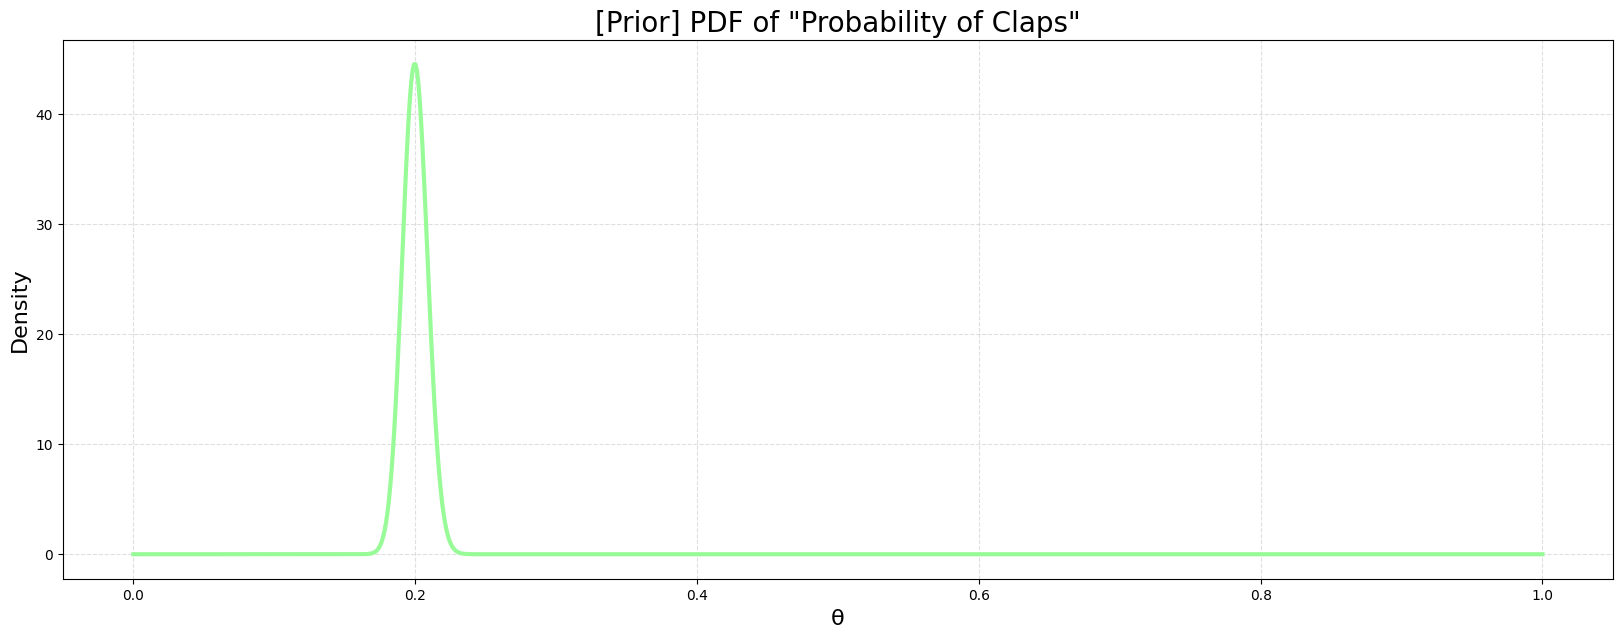

In [266]:
# Plotting the prior distribution
plt.rcParams['figure.figsize'] = [20, 7]
fig, ax = plt.subplots()
plt.plot(theta_range, prior, linewidth=3, color='palegreen')
# Add a title
plt.title('[Prior] PDF of "Probability of Claps"', fontsize=20)
# Add X and y Label
plt.xlabel('θ', fontsize=16)
plt.ylabel('Density', fontsize=16)
# Add a grid
plt.grid(alpha=.4, linestyle='--')
# Show the plot
plt.show()

In [267]:
# The sampling distribution P(X|θ) with a prior θ
likelihood = stats.binom.pmf(k = np.sum(clap_data), n = len(clap_data), p = a/(a+b))
likelihood

np.float64(1.62290041275183e-25)

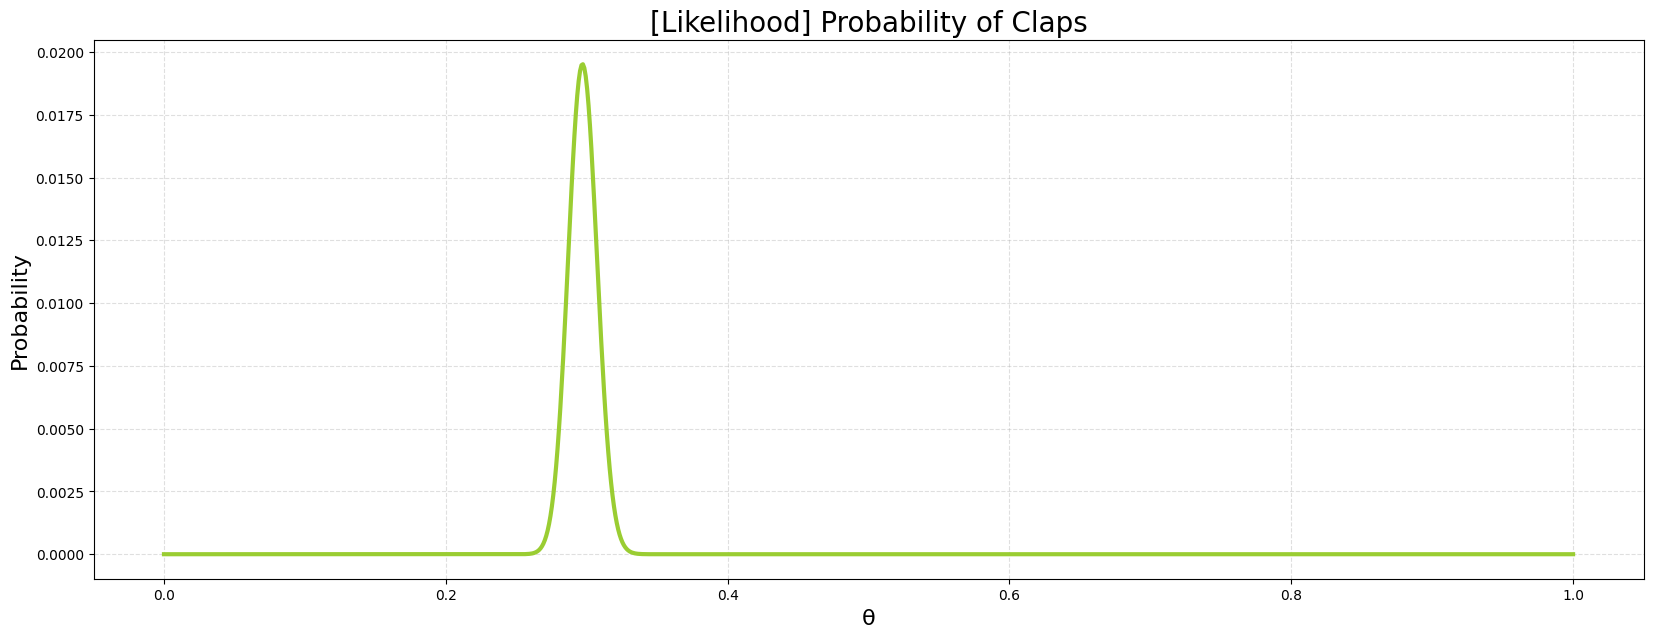

In [268]:
# Likelihood P(X|θ) for all θ's
likelihood = stats.binom.pmf(k = np.sum(clap_data), n = len(clap_data), p = theta_range)
# Create the plot
fig, ax = plt.subplots()
plt.plot(theta_range, likelihood, linewidth=3, color='yellowgreen')
# Add a title
plt.title('[Likelihood] Probability of Claps' , fontsize=20)
# Add X and y Label
plt.xlabel('θ', fontsize=16)
plt.ylabel('Probability', fontsize=16)
# Add a grid
plt.grid(alpha=.4, linestyle='--')
# Show the plot
plt.show()

In [269]:
from collections import defaultdict

columns = defaultdict(list)

# a_loc, b_loc = a, b
a_loc = 300 * 2
b_loc = 1000 * 2 - a_loc
# a_loc = 30 * 2
# b_loc = 100 * 2 - a_loc

for x in np.arange(len(clap_data) + 1):
    columns['θ'].extend(theta_range)
    columns['x'].extend([x] * len(theta_range))
    columns['p_θ'].extend(stats.beta.cdf(x=theta_range + 0.001, a=a_loc, b=b_loc) - stats.beta.cdf(x=theta_range, a=a_loc, b=b_loc))
    columns['p_x'].extend(stats.binom.pmf(x, n=len(clap_data), p=theta_range))

df = pd.DataFrame(columns)
df['p'] = df['p_θ'] * df['p_x']
df['p'].sum()

np.float64(0.9990000000000151)

In [270]:
df.shape

(2001000, 5)

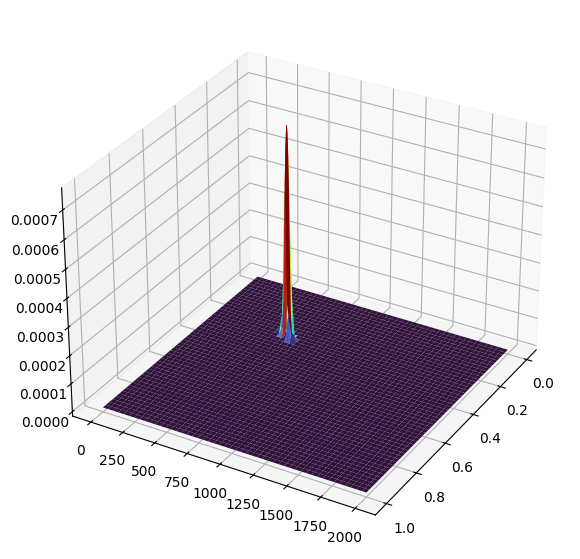

<Figure size 1800x1200 with 0 Axes>

In [271]:
fig = plt.figure()
plt.figure(figsize=(18, 12))
X, Y = np.meshgrid(theta_range, np.arange(len(clap_data) + 1))

ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, df['p'].to_numpy().reshape(-1, len(theta_range)), cmap='turbo')
ax.view_init(azim=30);#, elev=90);

In [18]:
theta_range_e = theta_range + 0.001 
'''
We calculated the prior by subtracting two stats.beta.cdf values instead of using stats.beta.pdf because the likelihood 
stats.binom.pmf is a probability, while stats.beta.pdf returns a density. Even if we use the density to calculate the posterior, 
it won’t change the optimization result. However, if you want the units to match, converting density into probability is necessary. 
(Still have questions? Read “PDF is NOT a probability, while PMF IS a probability”.)
'''
prior = stats.beta.cdf(x = theta_range_e, a=a, b=b) - stats.beta.cdf(x = theta_range, a=a, b=b) 
# prior = stats.beta.pdf(x = theta_range, a=a, b=b)
likelihood = stats.binom.pmf(k = np.sum(clap_data), n = len(clap_data), p = theta_range) 
posterior = likelihood * prior # element-wise multiplication
normalized_posterior = posterior / np.sum(posterior)

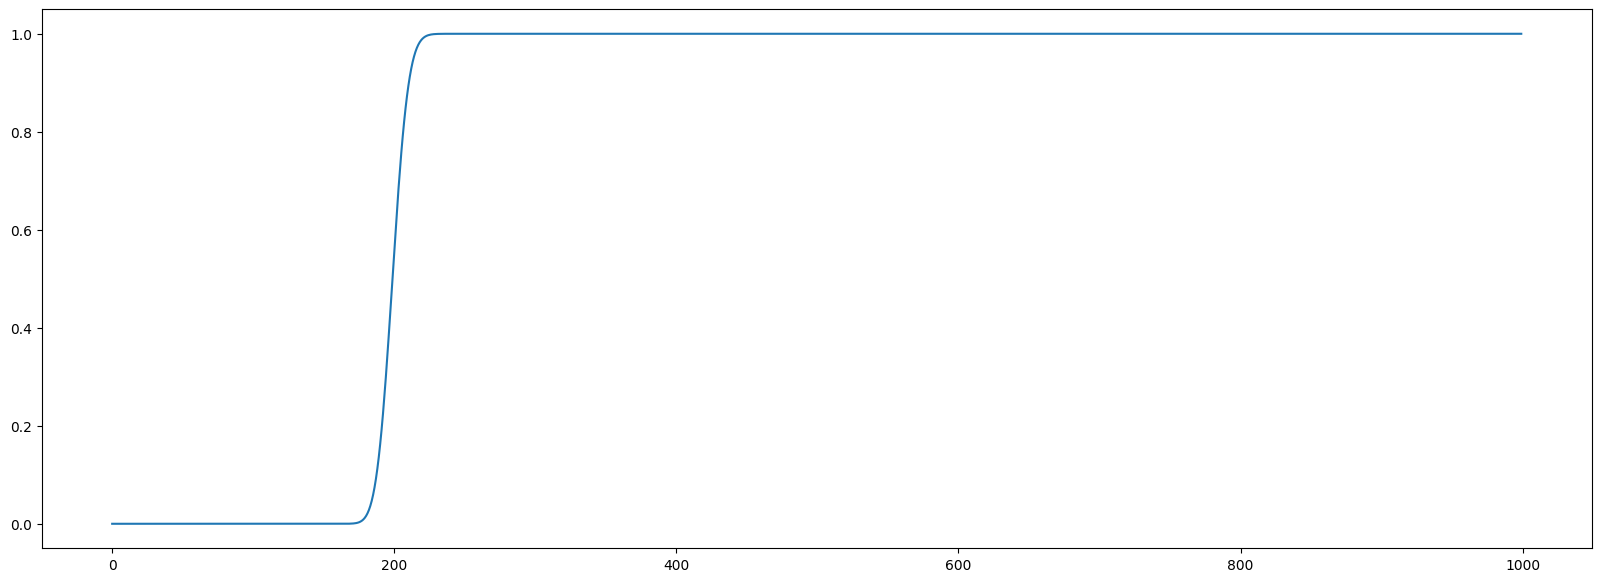

In [21]:
plt.plot(stats.beta.cdf(x = theta_range_e, a=a, b=b))

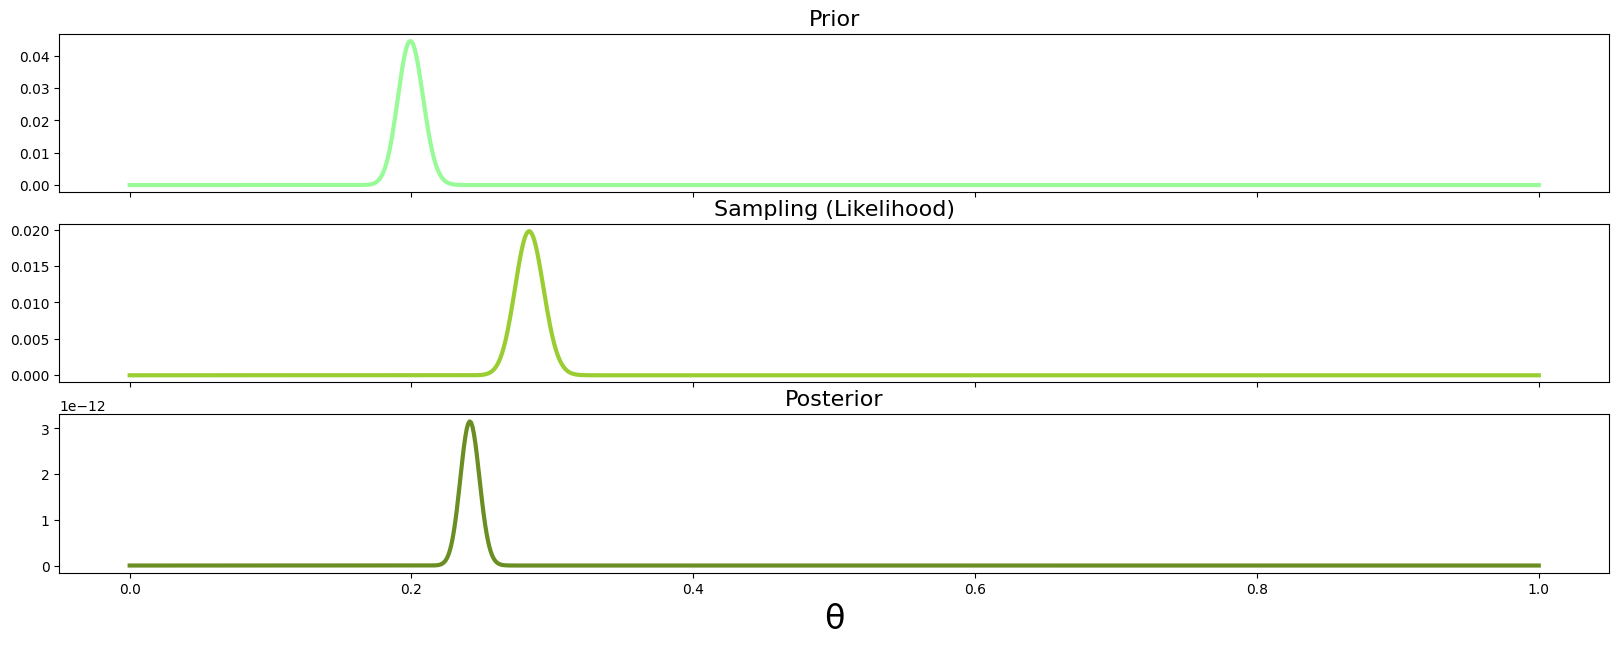

In [23]:
# Plotting all three together
fig, axes = plt.subplots(3, 1, sharex=True, figsize=(20,7))
plt.xlabel('θ', fontsize=24)
axes[0].plot(theta_range, prior, label="Prior", linewidth=3, color='palegreen')
axes[0].set_title("Prior", fontsize=16)
axes[1].plot(theta_range, likelihood, label="Likelihood", linewidth=3, color='yellowgreen')
axes[1].set_title("Sampling (Likelihood)", fontsize=16)
axes[2].plot(theta_range, posterior, label='Posterior', linewidth=3, color='olivedrab')
axes[2].set_title("Posterior", fontsize=16)
plt.show()

In [25]:
n_trials = [0, 1, 2, 3, 4, 5, 8, 15, 50, 500]
data = stats.bernoulli.rvs(0.5, size=n_trials[-1])
data

array([1, 1, 1, ..., 1, 1, 0])